In [26]:
from pathlib import Path
from google.colab import drive
from pathlib import Path
from google.colab import files

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:

nombre_imagen_reencuadre = "punto05.jpeg"

# Carpeta donde esta guardada la imagen en Drive
ruta_carpeta = Path(
    "/content/drive/MyDrive/2026/Técnicas de Procesamiento Digital de Imágenes - Matias Barreto/GITHUB REPO PROFE/cornes-valeria-pdi-1c-2026/TP_006/TP 006/IMAGENES/ORIGINALES"
)


ruta_imagen_reencuadre = ruta_carpeta / nombre_imagen_reencuadre

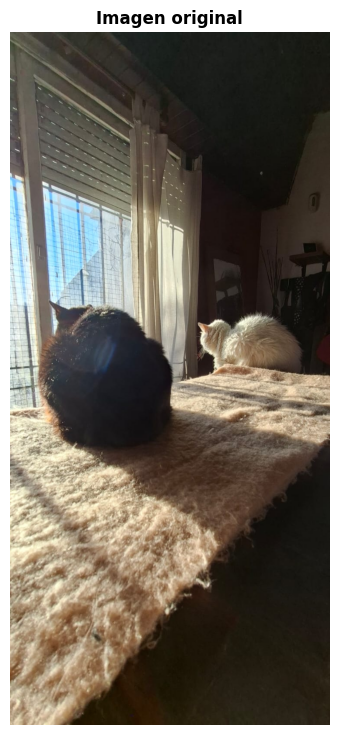

In [6]:
def cargar_rgb(ruta):
    """
    Abre una imagen color con OpenCV y la devuelve en formato RGB.
    OpenCV lee por defecto en BGR, por eso se convierte a RGB
    para visualizar correctamente con Matplotlib.
    """

    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)

    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")

    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

    return imagen_rgb


# Cargamos la imagen original
imagen_reencuadre_rgb = cargar_rgb(ruta_imagen_reencuadre)


# Mostramos la imagen original
plt.figure(figsize=(6, 9))
plt.imshow(imagen_reencuadre_rgb)
plt.title("Imagen original", fontweight="bold")
plt.axis("off")
plt.show()


A partir de una misma imagen original se realizaron dos reencuadres distintos. El Recorte A dirige la atención hacia la gata negra, generando una lectura más oscura e introspectiva. El Recorte B aísla a la gata blanca y produce una imagen más luminosa y contemplativa. Aunque la escena original es la misma, el cambio de encuadre modifica qué información se vuelve importante y qué elementos quedan fuera de la lectura visual.

In [22]:
# =========================
# 2. DEFINICION DE RECORTES
# =========================

# Formato: imagen[y1:y2, x1:x2]
# Ajustá estos valores si querés mover los encuadres.

# Recorte A: gata negra
y1_a, y2_a = 380, 1050
x1_a, x2_a = 0, 430

# Recorte B: gata blanca
y1_b, y2_b = 360, 980
x1_b, x2_b = 375, 720


crop_gata_negra = imagen_reencuadre_rgb[
    y1_a:y2_a,
    x1_a:x2_a
]

crop_gata_blanca = imagen_reencuadre_rgb[
    y1_b:y2_b,
    x1_b:x2_b
]

In [23]:

# =========================
# 3. MARCAR RECORTES SOBRE LA IMAGEN ORIGINAL
# =========================

imagen_marcada = imagen_reencuadre_rgb.copy()

# OpenCV dibuja en formato RGB si la imagen está en RGB.
# Rectángulo A: gata negra
cv2.rectangle(
    imagen_marcada,
    (x1_a, y1_a),
    (x2_a, y2_a),
    (255, 0, 0),
    5
)

cv2.putText(
    imagen_marcada,
    "Recorte A",
    (x1_a + 10, y1_a + 40),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (255, 0, 0),
    3
)

# Rectángulo B: gata blanca
cv2.rectangle(
    imagen_marcada,
    (x1_b, y1_b),
    (x2_b, y2_b),
    (0, 255, 0),
    5
)

cv2.putText(
    imagen_marcada,
    "Recorte B",
    (x1_b + 10, y1_b + 40),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0, 255, 0),
    3
)


array([[[ 96,  98,  84],
        [ 95,  97,  83],
        [ 93,  95,  81],
        ...,
        [ 24,  27,  20],
        [ 25,  28,  21],
        [ 24,  27,  20]],

       [[ 95,  97,  83],
        [ 94,  96,  82],
        [ 93,  95,  81],
        ...,
        [ 24,  27,  20],
        [ 25,  28,  21],
        [ 24,  27,  20]],

       [[ 94,  96,  82],
        [ 94,  96,  82],
        [ 93,  95,  81],
        ...,
        [ 24,  27,  20],
        [ 25,  28,  21],
        [ 24,  27,  20]],

       ...,

       [[202, 183, 150],
        [212, 193, 160],
        [223, 204, 172],
        ...,
        [ 45,  37,  24],
        [ 45,  37,  24],
        [ 45,  37,  24]],

       [[202, 183, 150],
        [203, 184, 151],
        [206, 187, 155],
        ...,
        [ 45,  37,  24],
        [ 45,  37,  24],
        [ 47,  39,  26]],

       [[210, 191, 158],
        [199, 180, 147],
        [192, 173, 141],
        ...,
        [ 45,  37,  24],
        [ 45,  37,  24],
        [ 46,  38,  25]]

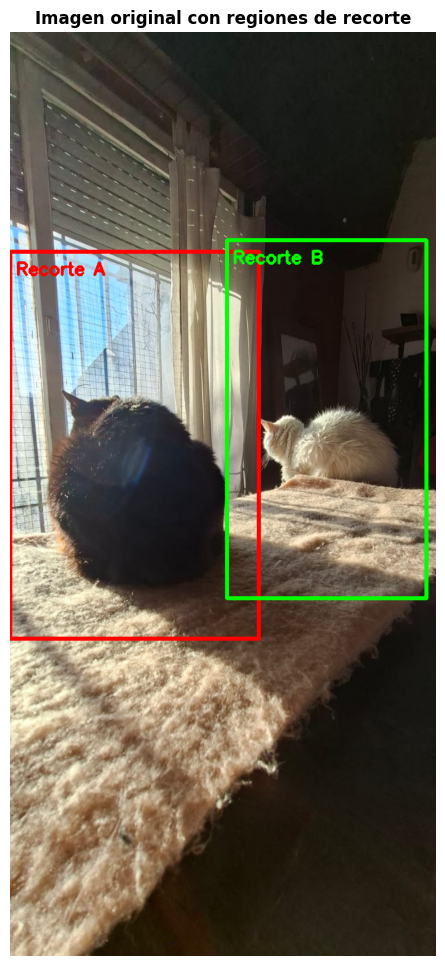

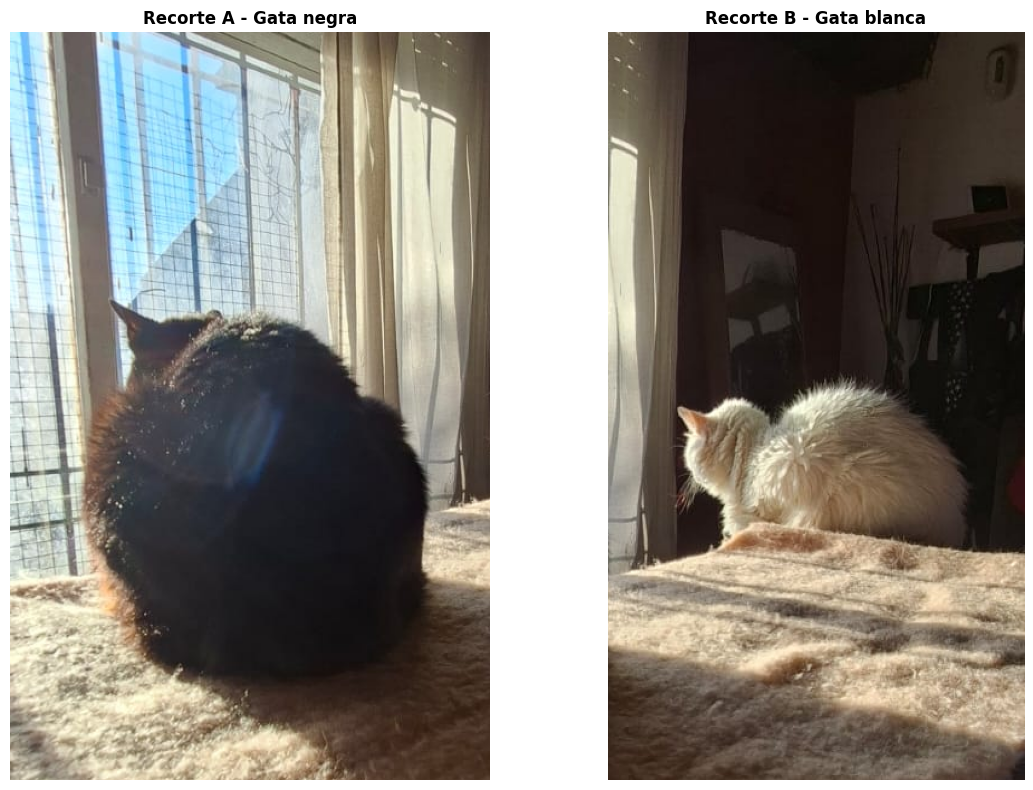

In [24]:

# =========================
# 4. VISUALIZACION
# =========================

plt.figure(figsize=(8, 12))
plt.imshow(imagen_marcada)
plt.title("Imagen original con regiones de recorte", fontweight="bold")
plt.axis("off")
plt.show()


plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.imshow(crop_gata_negra)
plt.title("Recorte A - Gata negra", fontweight="bold")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(crop_gata_blanca)
plt.title("Recorte B - Gata blanca", fontweight="bold")
plt.axis("off")

plt.tight_layout()
plt.show()



Después del crop se vuelve importante el sujeto elegido en cada recorte. En el Recorte A se prioriza la presencia de la gata negra y el contraste con la ventana. En el Recorte B se destaca la gata blanca y su relación con la luz. Desaparece parte del contexto general de la habitación, por lo que la imagen deja de leerse como una escena compartida y pasa a interpretarse como dos escenas independientes.

In [27]:

# =========================
# 5. EXPORTACION DIRECTA
# =========================

cv2.imwrite(
    "reencuadre_original_marcada.jpg",
    cv2.cvtColor(imagen_marcada, cv2.COLOR_RGB2BGR)
)

cv2.imwrite(
    "recorte_a_gata_negra.jpg",
    cv2.cvtColor(crop_gata_negra, cv2.COLOR_RGB2BGR)
)

cv2.imwrite(
    "recorte_b_gata_blanca.jpg",
    cv2.cvtColor(crop_gata_blanca, cv2.COLOR_RGB2BGR)
)


# Descarga directa
files.download("reencuadre_original_marcada.jpg")
files.download("recorte_a_gata_negra.jpg")
files.download("recorte_b_gata_blanca.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>